In [1]:
import numpy as np
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


In [41]:
%%R
library(eseis)
s <- read_mseed(
  file = "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240726120000.mseed",
  append = FALSE
)

class(s)                    # should include "eseis"
methods("plot")             # look for plot.eseis
getS3method("plot", "eseis", optional = TRUE)  # should not be NULL

# Peek at structure
str(s, max.level = 1)

List of 1
 $ :List of 4
  ..- attr(*, "class")= chr "eseis"


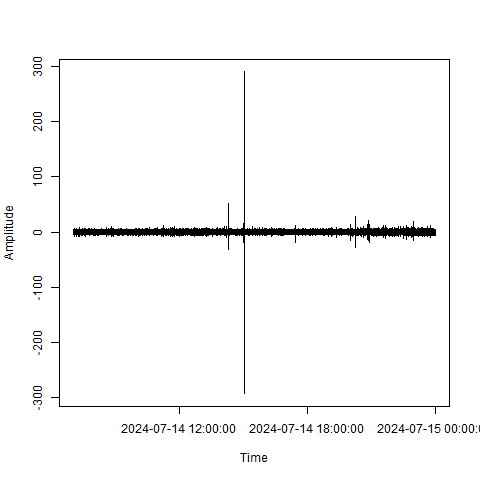

In [3]:
%%R
library(eseis)
Sys.setenv(TZ = "UTC")

dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

# Glob all files that begin with the 2024-07-14 date stamp
files_0714 <- Sys.glob(file.path(dir_gpz, "ZE.2416..GPZ_20240714*.mseed"))
length(files_0714)  # quick sanity check

stopifnot(length(files_0714) > 0)
s <- read_mseed(file = files_0714, append = TRUE)
plot(s)

## Here is correct workflow

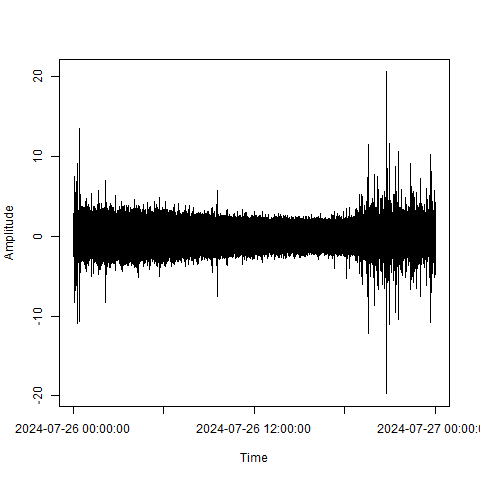

In [57]:
%%R
# for loading a single mseed
library(eseis)
Sys.setenv(TZ = "UTC")

dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

# Safer: convert your wildcard to a regex automatically
rx <- glob2rx("ZE.2416..GPZ_20240726*.mseed")
files_0726 <- list.files(path = dir_gpz, pattern = rx, full.names = TRUE)

stopifnot(length(files_0726) > 0)
s <- read_mseed(file = files_0726, append = TRUE)

# change size of plot
#options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle
plot(s)

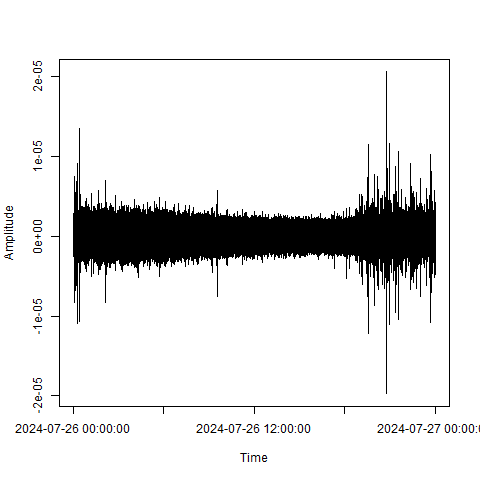

In [58]:
%%R
## convert to m/s
s$signal <- s$signal * 1e-6

# change size of plot
#options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle

## plot seismogram again
plot(s)

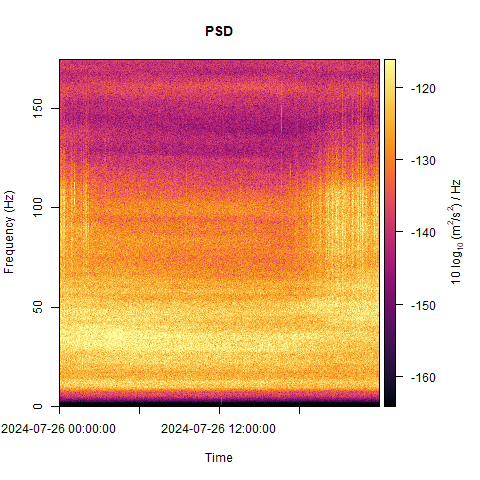

In [59]:
%%R
## calculate PSD
p <- signal_spectrogram(data = s, 
                        Welch = TRUE, 
                        window = 180, 
                        overlap = 0.5, 
                        window_sub = 60, 
                        overlap_sub = 0.5)

# change size of plot
#options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle

## plot PSD
plot(p)

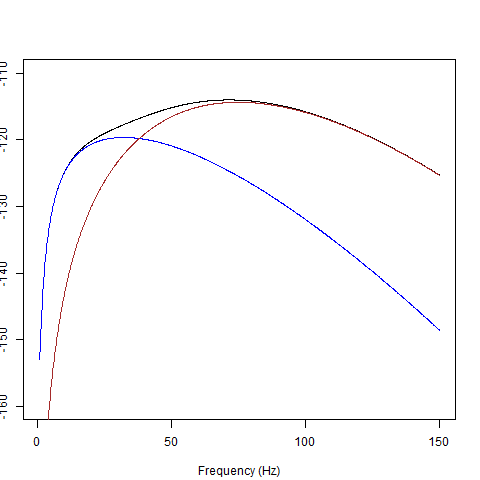

In [60]:
%%R
## predict a turbulence spectrum
p_w <- model_turbulence(d_s = 0.07,       # mean grain diameter
                        s_s = 0.5,        # sd of grain diameter
                        r_s = 2650,       # specific sediment density
                        h_w = 0.5,        # flow depth
                        w_w = 11,         # flow width
                        a_w = 0.1,        # slope angle (radians)
                        f = c(1, 150),    # freq range
                        r_0 = 14,         # distance from node to river
                        f_0 = 1,          # reference freq
                        q_0 = 20,         # ground quality factor (calibrate for this)
                        v_0 = 1200,       # rayleigh wave speed of f_0
                        p_0 = 0.48,       # power law variation of rayleigh velocities
                        n_0 = c(0.8, 1.0), # green's displacement amplitude coeff (gimbert eq 36)
                        depth = 0,        #
                        res = 1000,       # number of iterations
                        eseis = TRUE)     # return eseis object instead of df

# not using:
# adjust: adjust for wide grain size dist
# n_c: single particle hops in time, cause spectrum modulation, between 2-4
# e_0: exponent characterizing quality factor
# q_s: sediment flux value



## plot the spectrum
#plot(p_w)

## predict bedload spectrum
p_s <- model_bedload(d_s = 0.07, 
                     s_s = 0.5,
                     r_s = 2650,
                     q_s = 0.5 / 2650,
                     h_w = 0.5, 
                     w_w = 11, 
                     a_w = 0.1, 
                     f = c(1, 150), 
                     r_0 = 14,
                     f_0 = 1, 
                     q_0 = 20, 
                     e_0 = 0, 
                     v_0 = 1200,
                     p_0 = 0.48,
                     n_0 = 1.0, 
                     depth = 0, 
                     adjust = TRUE,
                     res = 1000,
                     eseis = TRUE)

## calculate combined spectrum
p_sum <- p_w
p_sum$spectrum$power <- p_w$spectrum$power + p_s$spectrum$power

# change size of plot
#options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle
par(pin = c(6, 5))   # plot INCHES: width=10, height=4

## plot combined spectra
plot(p_sum, ylim = c(-160, -110))
lines(p_w$spectrum$frequency, 10 * log10(p_w$spectrum$power), col = "blue")
lines(p_s$spectrum$frequency, 10 * log10(p_s$spectrum$power), col = "brown")


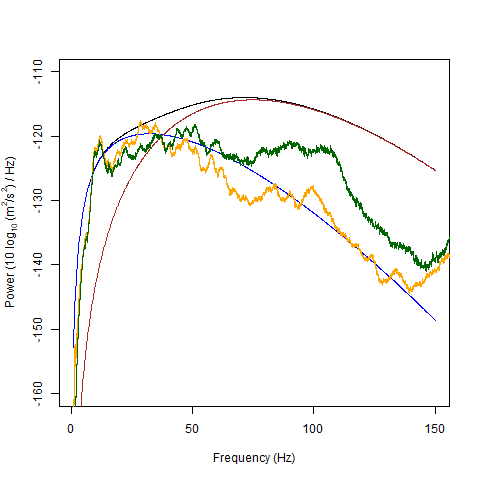

In [61]:
%%R
## load two files, but as list instead of as appended stream
# s_emp <- read_mseed(file = c("~/Downloads/Zoe/mseed/ZE.2416..GPZ_20240726120000.mseed",
#                              "~/Downloads/Zoe/mseed/ZE.2416..GPZ_20240726210000.mseed"), 
#                     append = FALSE)

s_emp <- read_mseed(file = c(list.files(path = dir_gpz, pattern = "ZE.2416..GPZ_20240726120000.mseed", full.names = TRUE),
                    list.files(path = dir_gpz, pattern = "ZE.2416..GPZ_20240726210000.mseed", full.names = TRUE)),
                    append = FALSE)

## correct both for velocity unit
s_emp[[1]]$signal <- s_emp[[1]]$signal * 1e-6
s_emp[[2]]$signal <- s_emp[[2]]$signal * 1e-6 

## calculate spectra, smoothed by 500 sample running mean
p_emp <- signal_spectrum(data = s_emp, n = 500)

# change size of plot
options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle

## plot combined spectra
plot(p_sum, ylim = c(-160, -110))
lines(p_w$spectrum$frequency, 10 * log10(p_w$spectrum$power), col = "blue")
lines(p_s$spectrum$frequency, 10 * log10(p_s$spectrum$power), col = "brown")
lines(p_emp[[1]]$spectrum$frequency, 10 * log10(p_emp[[1]]$spectrum$power), col = "orange")
lines(p_emp[[2]]$spectrum$frequency, 10 * log10(p_emp[[2]]$spectrum$power), col = "darkgreen")


In [62]:
%%R
## calculate a 10 min spectrogram
psd_emp <- signal_spectrogram(data = s, 
                              window = 600, 
                              overlap = 0)

#' Clip, interpolate (and optionally smoothen) a spectrogram
#' 
#' The function interpolates the power values in the frequency range defined 
#' by the user, applying a spline interpolator. This function can be used to 
#' extract a given frequency range or frequency band from a PSD. The former is 
#' useful for convenient preparation of the \code{fmi_} function family to 
#' achieve fluvial model inversion workflows. The latter is useful to create 
#' seismic power time series for a given frequency band. 
#' 
#' @param data \code{List} object, spectrogram to be processed. Must be the 
#' output of \code{signal_spectrogram} or of an equivalent structure.
#' 
#' @param f \code{Numeric} vector of length two, frequency range to which 
#' the PSD will be clipped. Alternatively, an empirical frequency vector can 
#' be submitted, too (e.g., when non-uniformly spaced frequencies are used).
#' 
#' @param res \code{Numeric} value, number of frequency values used as output 
#' of the frequency interpolation. If set to \code{1}, 
#' the input frequency range (\code{f}) will be averaged and a 
#' \code{data frame} with the elements \code{time} and \code{power} will 
#' be returned.
#' 
#' @param n \code{Numeric} value, number of values to use in a running average 
#' filter to smoothen the interpolated output. If omitted, the spectrogram 
#' will not be changed apart from the interpolation option.
#' 
#' @param dt \code{Numeric} value, sampling interval. Only required if 
#' \code{data} is no eseis object.
#' 
#' @return A clipped and interpolated spectrogram, or a data frame with 
#' a time series of an averaged frequency band.
#' 
#' @author Michael Dietze
#' 
#' @keywords eseis
#' 
#' @examples
#' 
#' ## load example data
#' data(rockfall)
#' 
#' ## calculate spectrogram
#' psd <- signal_spectrogram(data = rockfall_eseis)
#' 
#' ## Example 1: interpolate PSD to 5 to 15 Hz with 100 values resolution
#' psd_int <- aux_clipspectrogram(data = psd, f = c(5, 15), res = 100)
#' 
#' ## plot output
#' plot(psd_int)
#' 
#' ## Example 2: interpolate PSD using user defined frequency vector
#' psd_int <- aux_clipspectrogram(data = psd, f = sort(runif(n = 20, 5, 20)))
#' 
#' ## plot output
#' plot(psd_int)
#' 
#' ## Example 3: interpolate non-eseis matrix object
#' psd_int <- aux_clipspectrogram(data = psd$PSD$S, 
#'                                f = c(0, 10), 
#'                                res = 10, 
#'                                dt = 1/50)
#'                                
#' ## Example 4: extract a power time series for a frequency band
#' p_ts <- aux_clipspectrogram(data = psd, f = c(5, 10), res = 1)
#' plot(p_ts, type = "l")
#' 
#' ## Example 5: clip and smoothen the output
#' p_sm <- aux_clipspectrogram(data = psd, f = c(5, 20), res = 50, n = 10)
#' plot(p_sm)
#' 
#' @export aux_clipspectrogram

aux_clipspectrogram <- function(

  data,
  f,
  res = 100,
  n,
  dt
  
) {
  
  ## check for eseis object structure
  if(inherits(x = data, what = "eseis") == FALSE) {
    
    if(missing(f) | missing(res) | missing(dt)) {
      
      stop("The data is no eseis object and f, res and dt are missing!")
    } else {
      
      p <- data
      f_emp <- NA
    }
  } else {
    
    ## assign spectrogram object and frequency vector
    p <- data$PSD$S
    f_emp <- data$PSD$f
  }
  
  ## check/set interpolation frequency vector
  if(length(f) == 2) {
    
    ## check correct order of frequency limits
    if(f[1] >= f[2]) {
      
      stop("Lower frequency is not smaller than higher!")
    }

    ## build frequency vector
    f_int <- seq(from = f[1], to = f[2], length.out = res)
    
  } else {
    
    f_int <- f
  }
  
  ## optionally assign synthetic frequency vector
  if(any(is.na(f_emp))) {
    
    f_emp <- seq(from = 0, to = 1 / dt / 2, length.out = nrow(p))
  }

  ## average or interpolate data set
  if(res == 1) {
    
    ## calculate average power and frequency
    p_avg <- colMeans(p[f_emp >= f[1] & f_emp <= f[2],])

    ## get output time vector
    if(inherits(x = data, what = "eseis") == TRUE) {
      
      t_out <- data$PSD$t
    } else {
      
      t_out <- 1:length(p_avg)
    }
    
    ## create output data set
    data <- data.frame(time = t_out,
                       power = p_avg) 
    
    ## optionally smoothen data set
    if(missing(n) == FALSE) {
      
      data$power <- caTools::runmean(x = data$power, k = n)
    }
    
  } else {
    
    ## clip and interpolate PSD to frequency space of interest
    p_clip <- apply(X = p, MARGIN = 2, FUN = function(x, f_emp, f_int) {
      
      spline(x = f_emp, y = x, xout = f_int)$y
    }, f_emp, f_int)
    
    ## optionally, smoothen data set
    if(missing(n) == FALSE) {
      
      p_clip <- apply(X = p, MARGIN = 2, FUN = function(x, n) {
        
        caTools::runmean(x = x, k = n)
      }, n)
    }
    
    ## prepare output
    if(inherits(x = data, what = "eseis") == TRUE) {
      
      data$PSD$S <- p_clip
      data$PSD$f <- f_int
    } else {
      
      data <- p_clip
    }
  }
  
  ## return output
  return(data)
}

In addition: There were 50 or more warnings (use warnings() to see the first 50)


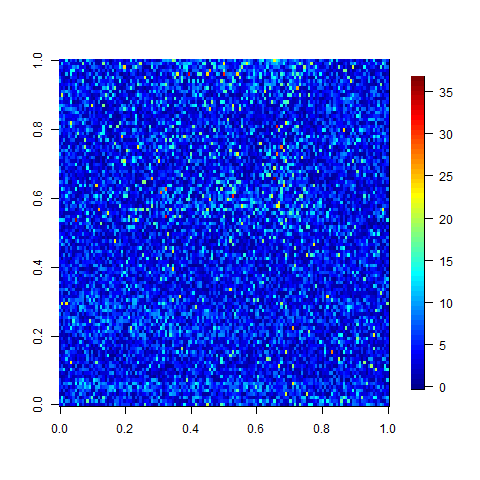

In [63]:
%%R

## clip and interpolate it to the frequency range to model (5-120 Hz)
psd_clp <- aux_clipspectrogram(data = psd_emp, 
                               f = c(5, 120), 
                               res = 100)

## define the parameters and the range of q_s and water level
fmi_par <- fmi_parameters(n = 1000,
                          d_s = 0.07, 
                          s_s = 0.5,
                          r_s = 2650,
                          q_s = c(0, 5) / 2650,
                          h_w = c(0.2, 2),
                          w_w = 11, 
                          a_w = 0.1, 
                          f_min = 5, 
                          f_max = 120, 
                          r_0 = 14,
                          f_0 = 1, 
                          q_0 = 20, 
                          e_0 = 0, 
                          v_0 = 1200,
                          p_0 = 0.48,
                          n_0_a = 0.8, 
                          n_0_b = 1.0, 
                          res = 100)

## pre-calculate spectra according to the above parameters
fmi_ref <- fmi_spectra(parameters = fmi_par)

## invert the data set
fmi_inv <- fmi_inversion(reference = fmi_ref, data = psd_clp)

# change size of plot
options(repr.plot.width = 10, repr.plot.height = 4)  # wide rectangle

# or get as a png??
# png("inv.png", width = 1200, height = 500)

## plot error matrix
fields::image.plot(fmi_inv$rmse)

# if png version, then this:
# dev.off() # might need devtools tho..idk

NULL


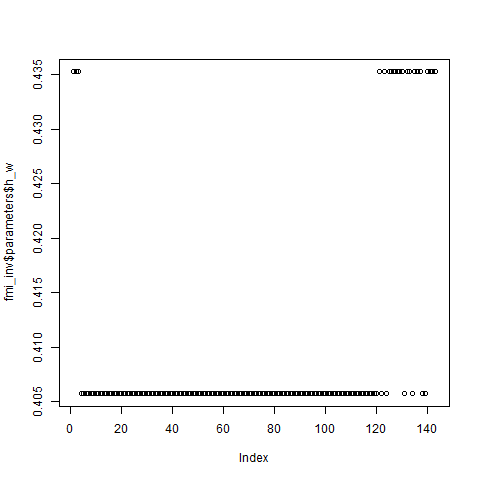

In [64]:
%%R
# plot time series of water level
plot(fmi_inv$parameters$h_w)
print(fmi_inv$parameters$p_w)

numeric(0)


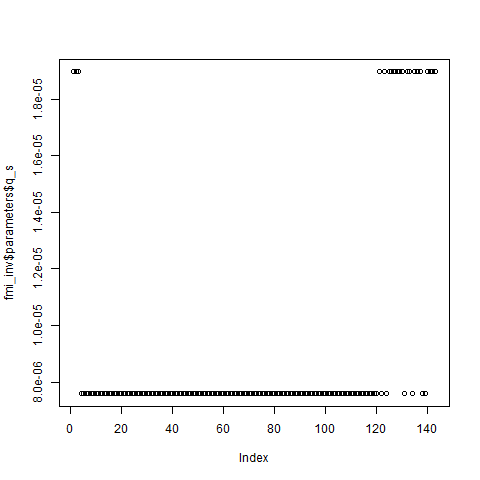

In [65]:
%%R
## plot time series of bedlaod flux
plot(fmi_inv$parameters$q_s) * 2650
print((fmi_inv$parameters$p_s)*2650)

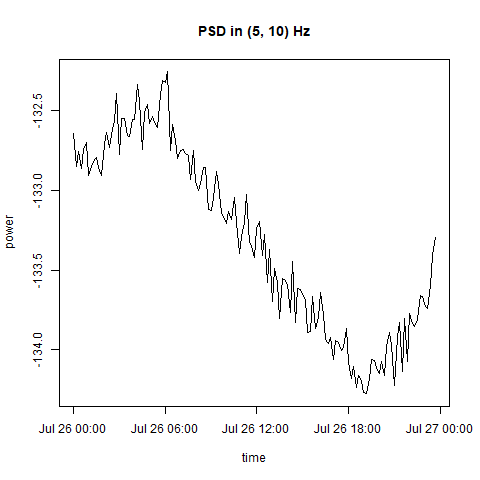

In [52]:
%%R
# plot seismic power over different freq bands
p_5_10 <- aux_clipspectrogram(data = psd_emp, f = c(5, 10), res = 1)
p_15_50 <- aux_clipspectrogram(data = psd_emp, f = c(15, 50), res = 1)
p_80_100 <- aux_clipspectrogram(data = psd_emp, f = c(80, 100), res = 1)

plot(p_5_10, type = "l", main = "PSD in (5, 10) Hz")

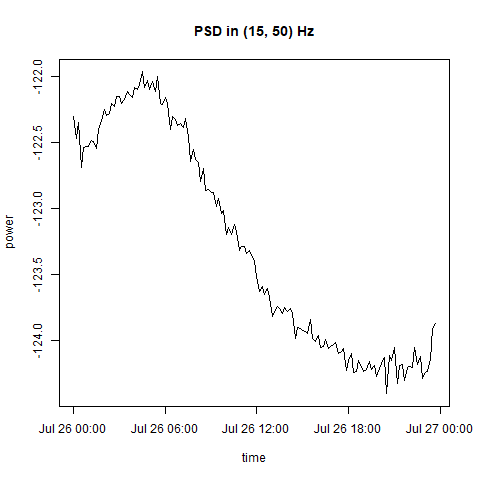

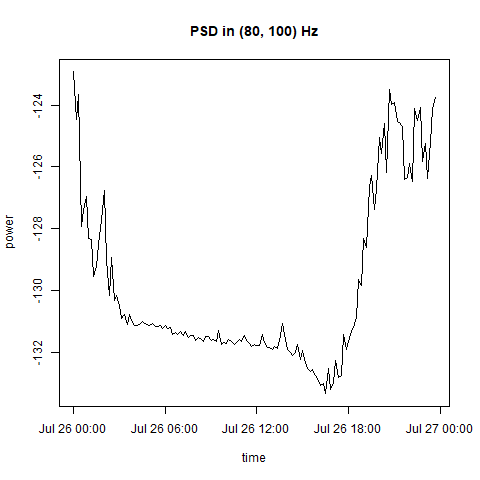

In [53]:
%%R
plot(p_15_50, type = "l", main = "PSD in (15, 50) Hz")
plot(p_80_100, type = "l", main = "PSD in (80, 100) Hz")

In [ ]:
unique(fml_inv$parameters$h_w)
unique(fml_inv$parameters$g_s)
str(fmi_inv$parameters)

In [ ]:
###???
run_inversion <- function(psd_file) {
  
  p <- readRDS(psd_file)
  
  psd_clp <- aux_clipspectrogram(
    data = p,
    f = c(5, 120),
    res = 100
  )
  
  fmi_inv <- fmi_inversion(
    reference = fmi_ref,
    data = psd_clp
  )
  
  return(list(
    q_s = fmi_inv$parameters$q_s,
    h_w = fmi_inv$parameters$h_w,
    rmse = min(fmi_inv$rmse)
  ))
}

results <- lapply(list.files(out_dir, full.names = TRUE), run_inversion)

In [ ]:
%%R
dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

# Choose EXACTLY the two files you want
files_two <- c(
  Sys.glob(file.path(dir_gpz, "ZE.2416..GPZ_20240726120000.mseed")),
  Sys.glob(file.path(dir_gpz, "ZE.2416..GPZ_20240726210000.mseed"))
)
stopifnot(length(files_two) == 2, all(file.exists(files_two)))

# (A) For model-comparison lines (orange/green curves):
s_emp <- read_mseed(file = files_two, append = FALSE)
# Apply velocity scaling ONCE
s_emp <- lapply(s_emp, function(x) { x$signal <- x$signal * 1e-6; x })
# Smooth per-file spectra
p_emp <- signal_spectrum(data = s_emp, n = 500)

# (B) For inversion (needs one continuous spectrogram):
s_stream <- read_mseed(file = files_two, append = TRUE)
s_stream$signal <- s_stream$signal * 1e-6

# Build spectrogram exactly as in HTML
psd_emp <- signal_spectrogram(data = s_stream, window = 600, overlap = 0)


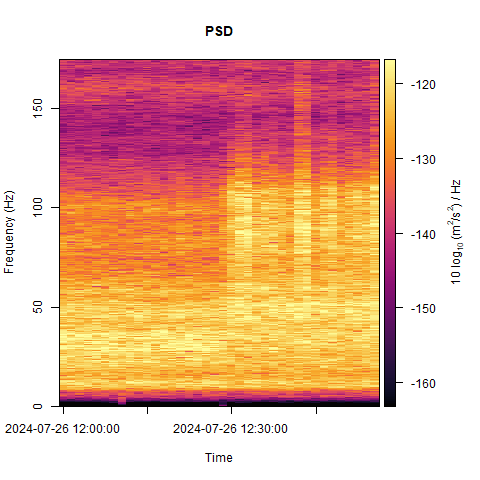

In [2]:
%%R

library(eseis)
Sys.setenv(TZ = "UTC")

dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

files_two <- c(
  Sys.glob(file.path(dir_gpz, "ZE.2416..GPZ_20240726120000.mseed")),
  Sys.glob(file.path(dir_gpz, "ZE.2416..GPZ_20240726210000.mseed"))
)

stopifnot(length(files_two) == 2)

# list style: good for per-file spectra (p_emp)
s_emp <- read_mseed(file = files_two, append = FALSE)


# apply velocity scaling
s_emp <- lapply(s_emp, function(x) { x$signal <- x$signal * 1e-6; x })

# smooth per-file spectra
p_emp <- signal_spectrum(data = s_emp, n = 500)

# stream style: good for one continuous spectrogram (psd_emp)
s_stream <- read_mseed(file = files_two, append = TRUE)
s_stream$signal <- s_stream$signal *1e-6

## calculate PSD
p <- signal_spectrogram(data = s_stream, 
                        Welch = TRUE, 
                        window = 180, 
                        overlap = 0.5, 
                        window_sub = 60, 
                        overlap_sub = 0.5)


## plot PSD
plot(p)



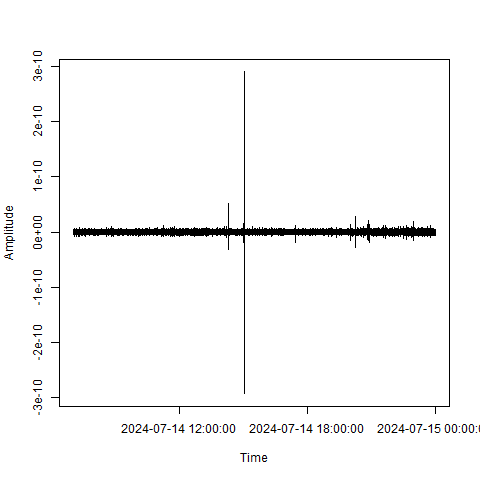

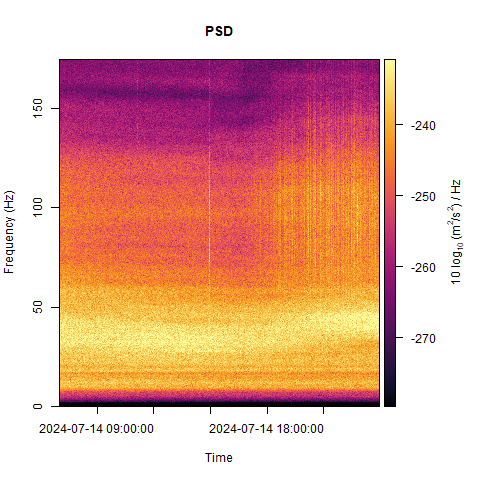

In [7]:
%%R
s$signal <- s$signal * 1e-6

## plot seismogram again
plot(s)

p <- signal_spectrogram(data = s, 
                        Welch = TRUE, 
                        window = 180, 
                        overlap = 0.5, 
                        window_sub = 60, 
                        overlap_sub = 0.5)


## plot PSD
plot(p)

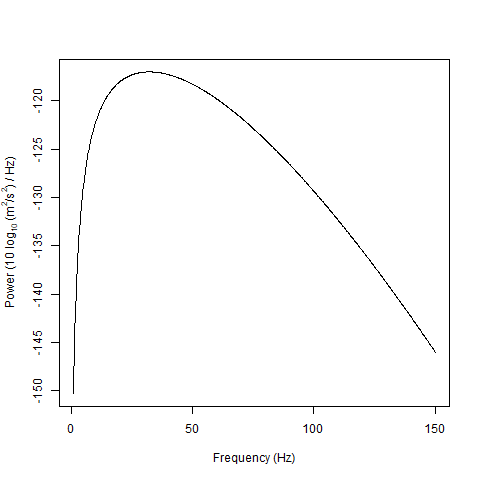

In [49]:
%%R
s$signal <- s$signal * 1e-6
## predict a turbulence spectrum
p_w <- model_turbulence(d_s = 0.07, 
                        s_s = 0.5, 
                        r_s = 2650, 
                        h_w = 0.5, 
                        w_w = 20, 
                        a_w = 0.1, 
                        f = c(1, 150), 
                        r_0 = 14, 
                        f_0 = 1, 
                        q_0 = 20, 
                        v_0 = 1200, 
                        p_0 = 0.48, 
                        n_0 = c(0.8, 1.0), 
                        depth = 0, res=1000,
                        eseis = TRUE)

## plot the spectrum
plot(p_w)

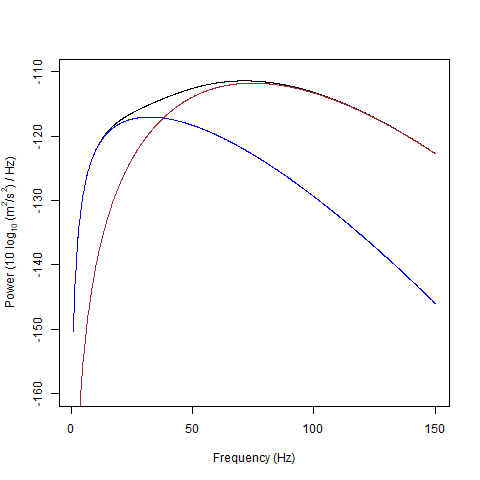

In [44]:
%%R
## predict bedload spectrum
p_s <- model_bedload(d_s = 0.07, 
                     s_s = 0.5,
                     r_s = 2650,
                     q_s = 0.5 / 2650,
                     h_w = 0.5, 
                     w_w = 20, 
                     a_w = 0.1, 
                     f = c(1, 150), 
                     r_0 = 14,
                     f_0 = 1, 
                     q_0 = 20, 
                     e_0 = 0, 
                     v_0 = 1200,
                     p_0 = 0.48,
                     n_0 = 1.0, 
                     depth = 0, 
                     adjust = TRUE, res=1000,
                     eseis = TRUE)

## calculate combined spectrum
p_sum <- p_w
p_sum$spectrum$power <- p_w$spectrum$power + p_s$spectrum$power

## plot combined spectra
plot(p_sum, ylim = c(-160, -110))
lines(p_w$spectrum$frequency, 10 * log10(p_w$spectrum$power), col = "blue")
lines(p_s$spectrum$frequency, 10 * log10(p_s$spectrum$power), col = "brown")

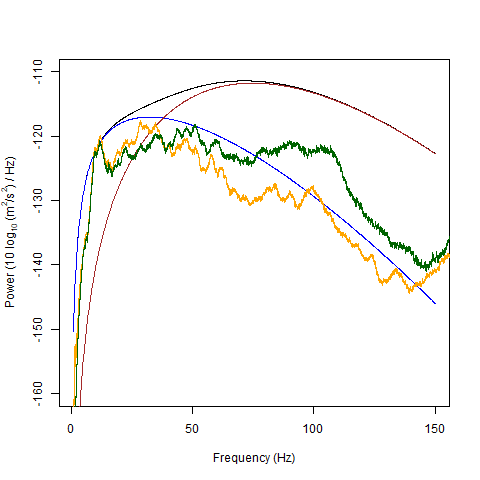

In [45]:
%%R
## load two files, but as list instead of as appended stream
s_emp <- read_mseed(file = c("C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240726120000.mseed",
                             "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240726210000.mseed"), 
                    append = FALSE)

## correct both for velocity unit
s_emp[[1]]$signal <- s_emp[[1]]$signal * 1e-6
s_emp[[2]]$signal <- s_emp[[2]]$signal * 1e-6 

## calculate spectra, smoothed by 500 sample running mean
p_emp <- signal_spectrum(data = s_emp, n = 500)

## plot combined spectra
plot(p_sum, ylim = c(-160, -110))
lines(p_w$spectrum$frequency, 10 * log10(p_w$spectrum$power), col = "blue")
lines(p_s$spectrum$frequency, 10 * log10(p_s$spectrum$power), col = "brown")
lines(p_emp[[1]]$spectrum$frequency, 10 * log10(p_emp[[1]]$spectrum$power), col = "orange")
lines(p_emp[[2]]$spectrum$frequency, 10 * log10(p_emp[[2]]$spectrum$power), col = "darkgreen")

In [37]:
%%R
psd_emp <- signal_spectrogram(data = s, 
                              window = 600, 
                              overlap = 0)


#' Clip, interpolate (and optionally smoothen) a spectrogram
#' 
#' The function interpolates the power values in the frequency range defined 
#' by the user, applying a spline interpolator. This function can be used to 
#' extract a given frequency range or frequency band from a PSD. The former is 
#' useful for convenient preparation of the \code{fmi_} function family to 
#' achieve fluvial model inversion workflows. The latter is useful to create 
#' seismic power time series for a given frequency band. 
#' 
#' @param data \code{List} object, spectrogram to be processed. Must be the 
#' output of \code{signal_spectrogram} or of an equivalent structure.
#' 
#' @param f \code{Numeric} vector of length two, frequency range to which 
#' the PSD will be clipped. Alternatively, an empirical frequency vector can 
#' be submitted, too (e.g., when non-uniformly spaced frequencies are used).
#' 
#' @param res \code{Numeric} value, number of frequency values used as output 
#' of the frequency interpolation. If set to \code{1}, 
#' the input frequency range (\code{f}) will be averaged and a 
#' \code{data frame} with the elements \code{time} and \code{power} will 
#' be returned.
#' 
#' @param n \code{Numeric} value, number of values to use in a running average 
#' filter to smoothen the interpolated output. If omitted, the spectrogram 
#' will not be changed apart from the interpolation option.
#' 
#' @param dt \code{Numeric} value, sampling interval. Only required if 
#' \code{data} is no eseis object.
#' 
#' @return A clipped and interpolated spectrogram, or a data frame with 
#' a time series of an averaged frequency band.
#' 
#' @author Michael Dietze
#' 
#' @keywords eseis
#' 
#' @examples
#' 
#' ## load example data
#' data(rockfall)
#' 
#' ## calculate spectrogram
#' psd <- signal_spectrogram(data = rockfall_eseis)
#' 
#' ## Example 1: interpolate PSD to 5 to 15 Hz with 100 values resolution
#' psd_int <- aux_clipspectrogram(data = psd, f = c(5, 15), res = 100)
#' 
#' ## plot output
#' plot(psd_int)
#' 
#' ## Example 2: interpolate PSD using user defined frequency vector
#' psd_int <- aux_clipspectrogram(data = psd, f = sort(runif(n = 20, 5, 20)))
#' 
#' ## plot output
#' plot(psd_int)
#' 
#' ## Example 3: interpolate non-eseis matrix object
#' psd_int <- aux_clipspectrogram(data = psd$PSD$S, 
#'                                f = c(0, 10), 
#'                                res = 10, 
#'                                dt = 1/50)
#'                                
#' ## Example 4: extract a power time series for a frequency band
#' p_ts <- aux_clipspectrogram(data = psd, f = c(5, 10), res = 1)
#' plot(p_ts, type = "l")
#' 
#' ## Example 5: clip and smoothen the output
#' p_sm <- aux_clipspectrogram(data = psd, f = c(5, 20), res = 50, n = 10)
#' plot(p_sm)
#' 
#' @export aux_clipspectrogram

aux_clipspectrogram <- function(

  data,
  f,
  res = 100,
  n,
  dt
  
) {
  
  ## check for eseis object structure
  if(inherits(x = data, what = "eseis") == FALSE) {
    
    if(missing(f) | missing(res) | missing(dt)) {
      
      stop("The data is no eseis object and f, res and dt are missing!")
    } else {
      
      p <- data
      f_emp <- NA
    }
  } else {
    
    ## assign spectrogram object and frequency vector
    p <- data$PSD$S
    f_emp <- data$PSD$f
  }
  
  ## check/set interpolation frequency vector
  if(length(f) == 2) {
    
    ## check correct order of frequency limits
    if(f[1] >= f[2]) {
      
      stop("Lower frequency is not smaller than higher!")
    }

    ## build frequency vector
    f_int <- seq(from = f[1], to = f[2], length.out = res)
    
  } else {
    
    f_int <- f
  }
  
  ## optionally assign synthetic frequency vector
  if(any(is.na(f_emp))) {
    
    f_emp <- seq(from = 0, to = 1 / dt / 2, length.out = nrow(p))
  }

  ## average or interpolate data set
  if(res == 1) {
    
    ## calculate average power and frequency
    p_avg <- colMeans(p[f_emp >= f[1] & f_emp <= f[2],])

    ## get output time vector
    if(inherits(x = data, what = "eseis") == TRUE) {
      
      t_out <- data$PSD$t
    } else {
      
      t_out <- 1:length(p_avg)
    }
    
    ## create output data set
    data <- data.frame(time = t_out,
                       power = p_avg) 
    
    ## optionally smoothen data set
    if(missing(n) == FALSE) {
      
      data$power <- caTools::runmean(x = data$power, k = n)
    }
    
  } else {
    
    ## clip and interpolate PSD to frequency space of interest
    p_clip <- apply(X = p, MARGIN = 2, FUN = function(x, f_emp, f_int) {
      
      spline(x = f_emp, y = x, xout = f_int)$y
    }, f_emp, f_int)
    
    ## optionally, smoothen data set
    if(missing(n) == FALSE) {
      
      p_clip <- apply(X = p, MARGIN = 2, FUN = function(x, n) {
        
        caTools::runmean(x = x, k = n)
      }, n)
    }
    
    ## prepare output
    if(inherits(x = data, what = "eseis") == TRUE) {
      
      data$PSD$S <- p_clip
      data$PSD$f <- f_int
    } else {
      
      data <- p_clip
    }
  }
  
  ## return output
  return(data)
}

# #install.packages("aux_clipspectrogram")
# library("C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/R/Raux_clipspectrogram)
# ## clip and interpolate it to the frequency range to model (5-120 Hz)
psd_clp <- aux_clipspectrogram(data = psd_emp, 
                               f = c(5, 120), 
                               res = 100)

# aux_clipspectrogram <- function(data, f, res = 100) {
#     f_vec <- data$PSD$f
#     p_vec <- data$power
#     S_mat <- data$PSD$S 

#     idx <- which(f_vec >= f[1] & f_vec <= f[2])
#     f_band <- f_vec[idx]
#     S_band <- S_mat[idx, , drop = FALSE]
#     f_new <- seq(f[1], f[2], length.out = res)
#     S_interp <- apply(S_band, 2, function(x) {
#         approx(f_band, x, xout = f_new)$y
#         })
#         colMeans(S_interp, na.rm = TRUE)
#                       }


In addition: There were 50 or more warnings (use warnings() to see the first 50)


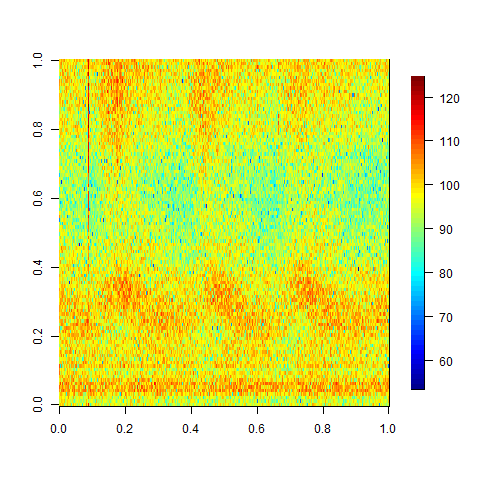

In [39]:
%%R
## define the parameters and the range of q_s and water level
fmi_par <- fmi_parameters(n = 1000,
                          d_s = 0.07, 
                          s_s = 0.5,
                          r_s = 2650,
                          q_s = c(0, 5) / 2650,
                          h_w = c(0.2, 2),
                          w_w = 11, 
                          a_w = 0.1, 
                          f_min = 5, 
                          f_max = 120, 
                          r_0 = 14,
                          f_0 = 1, 
                          q_0 = 20, 
                          e_0 = 0, 
                          v_0 = 1200,
                          p_0 = 0.48,
                          n_0_a = 0.8, 
                          n_0_b = 1.0, 
                          res = 100)


## pre-calculate spectra according to the above parameters
fmi_ref <- fmi_spectra(parameters = fmi_par)

## invert the data set
fmi_inv <- fmi_inversion(reference = fmi_ref, data = psd_clp)

install.packages("fields")
#library(fields)
## plot error matrix
fields::image.plot(fmi_inv$rmse)

In [ ]:
%%R
## if want to use files across multiple days based on file pattern with date list
library(eseis)
Sys.setenv(TZ = "UTC")

dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

# build globs for 2024-07-14 to 2024-07-17
days <- c("20240714", "20240715", "20240716", "20240717") # input desired days

files <- unlist(
  lapply(days, function(d)
    Sys.glob(file.path(dir_gpz, paste0("ZE.2416..GPZ_", d, "*.mseed")))
  )
)

length(files)   # sanity check
# stopifnot(length(files) > 0)

s <- read_mseed(file = files, append = TRUE)
plot(s)

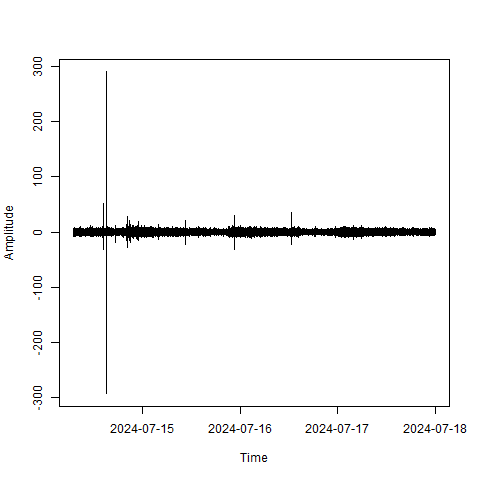

In [15]:
%%R
## if want to use files across multiple days based on file pattern by editing path range

library(eseis)
Sys.setenv(TZ = "UTC")

dir_gpz <- "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ"

# Regex for 2024-07-14 through 2024-07-17
rx <- "ZE\\.2416\\.\\.GPZ_2024071[4-7].*\\.mseed$"

files <- list.files(path = dir_gpz, pattern = rx, full.names = TRUE)

length(files)
s <- read_mseed(file = files, append = TRUE)
plot(s)


In [16]:
%%R
str(s$meta, max.level = 1)

summary(s$signal)
range(s$signal)


List of 14
 $ station  : chr "2416"
 $ network  : chr "ZE"
 $ component: chr "GPZ"
 $ n        : int 112140000
 $ sensor   : NULL
 $ logger   : NULL
 $ starttime: POSIXct[1:1], format: "2024-07-14 07:00:00"
 $ dt       : num 0.00286
 $ latitude : NULL
 $ longitude: NULL
 $ elevation: NULL
 $ depth    : NULL
 $ filename : chr [1:178] "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240714070000.mseed" "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240714073000.mseed" "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240714080000.mseed" "C:/Users/zzawol/OneDrive - DOI/Documents/MORA25/iris-data/seismic_data/NO2416/GPZ/ZE.2416..GPZ_20240714083000.mseed" ...
 $ type     : chr "waveform"
[1] -292.4612  289.8933
